In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt     
from PostprocessingFunctions import write_vtk

In [3]:
%%bash
cd ..
g++ -std=c++17 -Wall Ramp.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o RampMMS 

        

SRC/Flux.cpp: In member function ‘void Flux::compute_residual()’:
SRC/Flux.cpp:575:14: warning: unused variable ‘ghost_flag’ [-Wunused-variable]
  575 |         bool ghost_flag = false;
      |              ^~~~~~~~~~


In [4]:
%%bash
cd ..
./RampMMS

Shape = (832, 4)
setting pointersSetting ambient Conditions...Setting inflow Conditions...Iteration: 0
Upwind Order: 0;  Norms:
  Density   : 0.000262441  U-velocity: 0.151252  V-velocity: 1.59665e-17  Pressure  : 57.2059
Iteration: 1
Upwind Order: 0;  Norms:
  Density   : 0.00026243  U-velocity: 0.151229  V-velocity: 2.87588e-05  Pressure  : 57.2033
Iteration: 2
Upwind Order: 0;  Norms:
  Density   : 0.000262419  U-velocity: 0.151205  V-velocity: 5.75258e-05  Pressure  : 57.2006
Iteration: 3
Upwind Order: 0;  Norms:
  Density   : 0.000262407  U-velocity: 0.151182  V-velocity: 8.63009e-05  Pressure  : 57.198
Iteration: 4
Upwind Order: 0;  Norms:
  Density   : 0.000262396  U-velocity: 0.151158  V-velocity: 0.000115084  Pressure  : 57.1953
Iteration: 5
Upwind Order: 0;  Norms:
  Density   : 0.000262385  U-velocity: 0.151135  V-velocity: 0.000143876  Pressure  : 57.1926
Iteration: 6
Upwind Order: 0;  Norms:
  Density   : 0.000262374  U-velocity: 0.151111  V-velocity: 0.000172675  Pressure

Upwind Order: 0;  Norms:
  Density   : 0.000262319  U-velocity: 0.150993  V-velocity: 0.000316797  Pressure  : 57.1767
Iteration: 12
Upwind Order: 0;  Norms:
  Density   : 0.000262307  U-velocity: 0.15097  V-velocity: 0.000345647  Pressure  : 57.1741
Iteration: 13
Upwind Order: 0;  Norms:
  Density   : 0.000262296  U-velocity: 0.150946  V-velocity: 0.000374504  Pressure  : 57.1714
Iteration: 14
Upwind Order: 0;  Norms:
  Density   : 0.000262285  U-velocity: 0.150923  V-velocity: 0.00040337  Pressure  : 57.1688
Iteration: 15
Upwind Order: 0;  Norms:
  Density   : 0.000262274  U-velocity: 0.150899  V-velocity: 0.000432244  Pressure  : 57.1661
Iteration: 16
Upwind Order: 0;  Norms:
  Density   : 0.000262263  U-velocity: 0.150876  V-velocity: 0.000461127  Pressure  : 57.1635
Iteration: 17
Upwind Order: 0;  Norms:
  Density   : 0.000262252  U-velocity: 0.150852  V-velocity: 0.000490018  Pressure  : 57.1609
Iteration: 18
Upwind Order: 0;  Norms:
  Density   : 0.000262241  U-velocity: 0.15082

In [5]:


data = np.loadtxt("../primitives.csv", delimiter=",")
NI = 16
NJ = 52
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(4, 832)


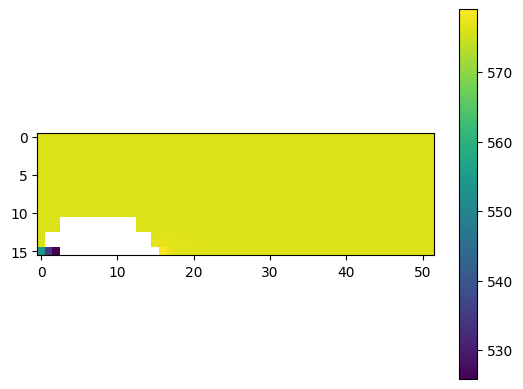

In [6]:
plt.imshow(u[::-1])
plt.colorbar()

In [7]:
from PostprocessingFunctions import load_grid
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.209x65.grd")



TypeError: Dimensions of C (16, 52) should be one smaller than X(209) and Y(65) while using shading='flat' see help(pcolormesh)

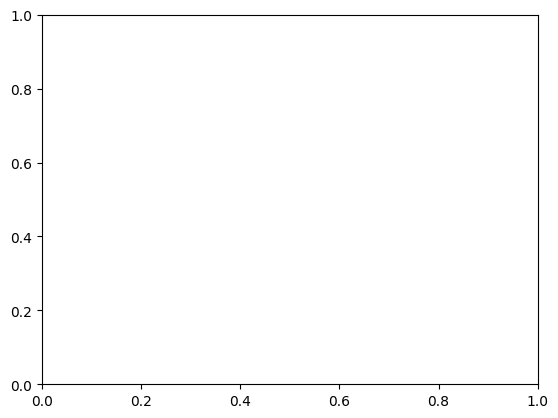

In [8]:
 

plt.pcolormesh(x, y, rho, shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



In [ ]:
write_vtk("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.209x65.grd",rho,u,v,p,output_name="../VTK/Fine_Ramp.vtk")